# Lista – Modelagem Preditiva e Séries Temporais com IA

## Exercício 1 – Regressão Logística para Probabilidade de Compra de SUV

**Aluno:** André Douglas da Silva Cruz

**Matrícula:** 1665898

**Disciplina:** Modelagem Preditiva e Séries Temporais com IA

**Professora:** Anaíle Mendes Rabelo

# 1. Importação das Bibliotecas

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# 2. Carregamento da Base de Dados

In [2]:
df = pd.read_csv('SUV_Network_Ads (3).csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


# 3. Análise Descritiva

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [5]:
df.describe()

,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


In [6]:
df.isnull().sum()

,0
User ID,0
Gender,0
Age,0
EstimatedSalary,0
Purchased,0


In [7]:
df['Purchased'].value_counts()

,count
Purchased,
0,257
1,143


In [8]:
df['Purchased'].value_counts(normalize=True) * 100

,proportion
Purchased,
0,64.25
1,35.75


### Interpretação da Análise Descritiva

A base de dados é composta por **400 observações** e contém informações sobre idade, salário estimado e decisão de compra de uma SUV.

A verificação da estrutura da base permitiu identificar as variáveis disponíveis e seus respectivos tipos de dados, enquanto a análise das estatísticas descritivas possibilitou compreender a distribuição das variáveis numéricas.

A análise de valores ausentes demonstrou que não existem registros nulos na base de dados, permitindo a utilização de todas as observações na construção do modelo de regressão logística.

Em relação à variável alvo (**Purchased**), observou-se que **257 usuários (64,25%) não compraram a SUV**, enquanto **143 usuários (35,75%) realizaram a compra**. Embora exista predominância da classe "não comprou", a distribuição ainda é adequada para a construção e avaliação de um modelo de classificação.

De forma geral, a base apresenta boa qualidade, ausência de valores faltantes e quantidade suficiente de observações para o desenvolvimento do modelo de regressão logística.

# 4. Modelo de Regressão Logística

## Preparação das Variáveis

In [9]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [11]:
X_train_const = sm.add_constant(X_train)
X_test_const = sm.add_constant(X_test)

In [12]:
modelo_logistico = sm.Logit(y_train, X_train_const).fit()

Optimization terminated successfully.
         Current function value: 0.337717
         Iterations 8


In [13]:
modelo_logistico.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:              Purchased   No. Observations:                  300
Model:                          Logit   Df Residuals:                      297
Method:                           MLE   Df Model:                            2
Date:                Mon, 06 Jul 2026   Pseudo R-squ.:                  0.4816
Time:                        19:09:24   Log-Likelihood:                -101.32
converged:                       True   LL-Null:                       -195.44
Covariance Type:            nonrobust   LLR p-value:                 1.321e-41
===================================================================================
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -12.1205      1.449     -8.363      0.000     -14.961      -9.280
Age                 0.2222      0.029      7.782      0.000       0.166       0.278
EstimatedSalary  3.775e-05   6.22e-06      6.065      0.000    2.56e-05       5e-05
===================================================================================
"""

### Interpretação do Modelo de Regressão Logística

O modelo de regressão logística foi construído para estimar a probabilidade de um usuário comprar uma SUV com base nas variáveis **Age** e **EstimatedSalary**.

O modelo convergiu corretamente, indicando que o processo de estimação foi concluído sem problemas.

O valor de **Pseudo R² = 0,4816** indica que o modelo apresenta capacidade explicativa relevante para um problema de classificação binária.

O teste geral do modelo apresentou **LLR p-value = 1,321e-41**, valor inferior a 0,05, indicando que o modelo é estatisticamente significativo.

A variável **Age** apresentou coeficiente positivo de **0,2222** e p-valor inferior a 0,05. Isso indica que, à medida que a idade aumenta, cresce também a chance de compra da SUV.

A variável **EstimatedSalary** também apresentou coeficiente positivo de **0,00003775** e p-valor inferior a 0,05. Isso indica que salários estimados mais altos estão associados a maior probabilidade de compra.

Dessa forma, conclui-se que tanto a idade quanto o salário estimado são variáveis relevantes para explicar a probabilidade de compra da SUV.

# 5. Análise dos Pressupostos e Validação do Modelo

## 5.1 Probabilidades Previstas

In [14]:
probabilidades = modelo_logistico.predict(X_test_const)

probabilidades.head()

,0
315,0.348851
349,0.201849
358,0.365189
200,0.053564
265,0.783845


## 5.2 Classificação das Observações

In [15]:
predicoes = (probabilidades >= 0.5).astype(int)

predicoes[:10]

,0
315,0
349,0
358,0
200,0
265,1
276,0
267,0
174,0
215,1
1,0


## 5.3 Matriz de Confusão

In [16]:
matriz = confusion_matrix(y_test, predicoes)

matriz

array([[60,  4],
       [12, 24]])

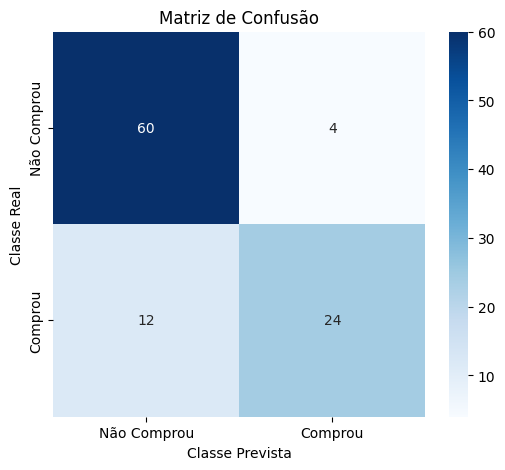

In [17]:
plt.figure(figsize=(6,5))

sns.heatmap(
    matriz,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Não Comprou', 'Comprou'],
    yticklabels=['Não Comprou', 'Comprou']
)

plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão')

plt.show()

## 5.4 Acurácia do Modelo

In [18]:
accuracy = accuracy_score(y_test, predicoes)

print(f'Acurácia: {accuracy:.4f}')

Acurácia: 0.8400


## 5.5 Relatório de Classificação

In [19]:
print(classification_report(y_test, predicoes))

              precision    recall  f1-score   support

           0       0.83      0.94      0.88        64
           1       0.86      0.67      0.75        36

    accuracy                           0.84       100
   macro avg       0.85      0.80      0.82       100
weighted avg       0.84      0.84      0.83       100



### Interpretação da Análise dos Pressupostos e Validação do Modelo

A validação do modelo foi realizada por meio da matriz de confusão, da acurácia e do relatório de classificação.

A matriz de confusão mostrou que o modelo classificou corretamente 60 usuários que não compraram a SUV e 24 usuários que realizaram a compra. Foram observados 4 falsos positivos e 12 falsos negativos.

A acurácia obtida foi de **84%**, indicando que o modelo realizou corretamente a classificação da maioria dos usuários da base de teste.

No relatório de classificação, a classe **0 (não comprou)** apresentou **precision de 0,83**, **recall de 0,94** e **F1-score de 0,88**, demonstrando excelente capacidade de identificar usuários que não realizaram a compra.

Para a classe **1 (comprou)**, o modelo apresentou **precision de 0,86**, **recall de 0,67** e **F1-score de 0,75**. Isso indica que, embora o modelo apresente boa precisão ao identificar compradores, parte deles ainda não é corretamente classificada, refletindo um recall inferior ao da classe 0.

De forma geral, os resultados demonstram que o modelo possui bom desempenho preditivo e capacidade satisfatória para estimar a probabilidade de compra de uma SUV.

# 6. Análise do Modelo

### Interpretação da Análise do Modelo

O modelo de regressão logística apresentou convergência adequada, indicando que o processo de estimação dos parâmetros foi realizado corretamente.

O valor de **Pseudo R² = 0,4816** indica que o modelo possui capacidade explicativa relevante para um problema de classificação binária.

O teste geral do modelo apresentou **LLR p-value = 1,321e-41**, valor inferior a 0,05. Isso demonstra que o modelo é estatisticamente significativo, ou seja, as variáveis utilizadas contribuem para explicar a probabilidade de compra da SUV.

A variável **Age** apresentou coeficiente positivo de **0,2222** e p-valor inferior a 0,05, indicando que o aumento da idade está associado ao aumento da probabilidade de compra.

A variável **EstimatedSalary** também apresentou coeficiente positivo de **0,00003775** e p-valor inferior a 0,05, indicando que usuários com maior salário estimado tendem a apresentar maior probabilidade de comprar a SUV.

A validação do modelo apresentou acurácia de **84%**, demonstrando bom desempenho preditivo na base de teste.

Dessa forma, conclui-se que o modelo é adequado para estimar a probabilidade de compra de uma SUV com base na idade e no salário estimado dos usuários.

# 7. Interpretação do Odds

In [20]:
odds_ratios = np.exp(modelo_logistico.params)

odds_ratios

,0
const,0.000005
Age,1.248798
EstimatedSalary,1.000038


In [25]:
odds_tabela = pd.DataFrame({
    'Variável': odds_ratios.index,
    'Coeficiente': modelo_logistico.params.values,
    'Odds Ratio': odds_ratios.values
})

odds_tabela

,Variável,Coeficiente,Odds Ratio
0,const,-12.120451,0.000005
1,Age,0.222181,1.248798
2,EstimatedSalary,0.000038,1.000038


### Interpretação do Odds

O Odds Ratio representa a variação nas chances de um usuário comprar uma SUV para cada aumento de uma unidade na variável explicativa, mantendo as demais variáveis constantes.

A variável **Age** apresentou Odds Ratio igual a **1,2488**, indicando que, para cada aumento de um ano na idade, as chances de compra da SUV aumentam aproximadamente **24,88%**, mantendo o salário estimado constante.

A variável **EstimatedSalary** apresentou Odds Ratio igual a **1,000038**. Embora esse valor seja muito próximo de 1, ele indica que aumentos no salário estimado estão associados ao aumento das chances de compra da SUV. Como o salário é medido em unidades monetárias individuais, o efeito de um único incremento é pequeno, mas torna-se mais perceptível quando são considerados aumentos maiores de renda.

O intercepto (const) apresentou Odds Ratio igual a **0,000005**. Esse parâmetro é utilizado para compor a equação do modelo e, isoladamente, não possui interpretação prática no contexto da compra da SUV.

Dessa forma, conclui-se que tanto a idade quanto o salário estimado influenciam positivamente a probabilidade de compra da SUV, sendo a idade a variável com maior impacto relativo no modelo.